In [1]:
%%writefile /tmp/study_cache.cpp
extern "C" long process(const unsigned char* arr, unsigned long n) {
    long total = 0;
    for (unsigned long i = 0; i < n; ++i) {
        unsigned char v = arr[i];
        if (v & 1) total += v;
        else total -= v;
    }
    return total;
}

Overwriting /tmp/study_cache.cpp


In [2]:
!g++ -std=c++23 -O3 -c /tmp/study_cache.cpp -o /tmp/study_cache.o

In [3]:
import pandas as pd

import perf

BASE = 0x10000000
payload = [(i * 37) % 256 for i in range(256)]


def cache(hit_rate):
    return {
        "cache": {
            "L1d": {"hit_rate": hit_rate},
            "L2": {"hit_rate": 100},
            "L3": {"hit_rate": 100},
            "L1i": {"hit_rate": 100},
        }
    }


frames = []
for hit_rate in (100, 0):
    df = perf.bench(
        exec="/tmp/study_cache.o",
        func="process",
        mode="latency",
        event="topdown-retiring,topdown-bad-spec,topdown-fe-bound,topdown-be-bound",
        data={"arg0": BASE, "arg1": 256, hex(BASE) + ":": payload},
        config={**cache(hit_rate), "samples": 40, "runs": 3, "iterations": 200},
    ).reset_index()
    df["hit_rate"] = hit_rate
    frames.append(df)
top = pd.concat(frames, ignore_index=True)
med = top.groupby("hit_rate")[
    ["topdown-retiring", "topdown-bad-spec", "topdown-fe-bound", "topdown-be-bound"]
].median()
pct = med.div(med.sum(axis=1), axis=0).round(3)
print(med.round(1))
print(pct)

          topdown-retiring  topdown-bad-spec  topdown-fe-bound  \
hit_rate                                                         
0                   2312.0              84.0              11.0   
100                 2312.0              74.0              11.0   

          topdown-be-bound  
hit_rate                    
0                   1568.0  
100                 1491.0  
          topdown-retiring  topdown-bad-spec  topdown-fe-bound  \
hit_rate                                                         
0                    0.582             0.021             0.003   
100                  0.595             0.019             0.003   

          topdown-be-bound  
hit_rate                    
0                    0.394  
100                  0.383  


In [4]:
import pandas as pd

import perf

frames = []
for hit_rate in (100, 0):
    df = perf.bench(
        exec="/tmp/study_cache.o",
        func="process",
        mode="latency",
        event="cycles,cache-references,cache-misses",
        data={"arg0": BASE, "arg1": 256, hex(BASE) + ":": payload},
        config={**cache(hit_rate), "samples": 40, "runs": 3, "iterations": 200},
    ).reset_index()
    df["hit_rate"] = hit_rate
    frames.append(df)
cmp = pd.concat(frames, ignore_index=True)
print(
    cmp.groupby("hit_rate")[["cycles", "cache-references", "cache-misses"]]
    .median()
    .round(1)
)

          cycles  cache-references  cache-misses
hit_rate                                        
0          784.0               0.0           0.0
100        773.5               0.0           0.0


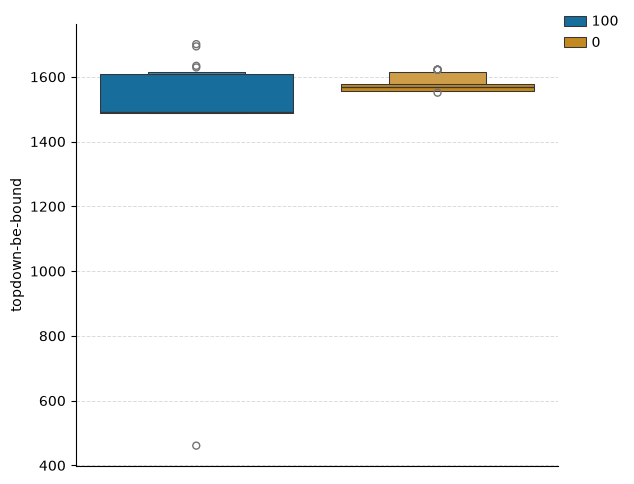

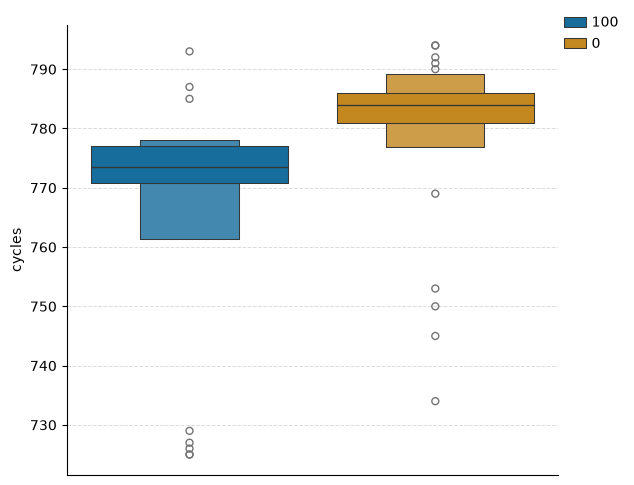

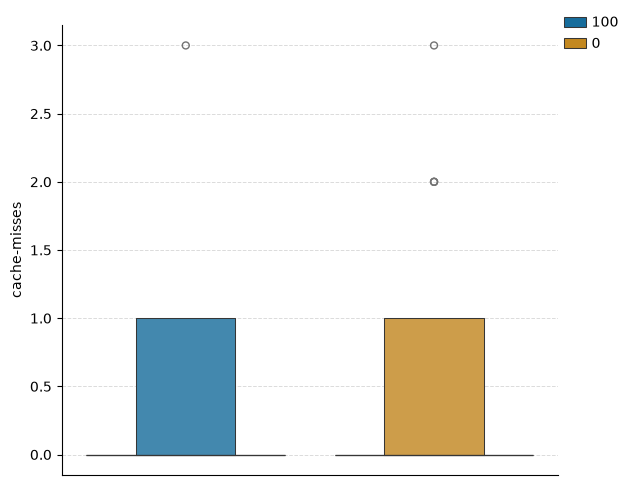

[]

In [5]:
perf.plot(top, "boxen", event="topdown-be-bound", groupby="hit_rate")
perf.plot(cmp, "boxen", event="cycles", groupby="hit_rate")
perf.plot(cmp, "boxen", event="cache-misses", groupby="hit_rate")